## A comparison study of solar power prediction using different machine learning models

### Prepared by:
### Meena Sankari N

In [1]:
#importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, BayesianRidge
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from statsmodels.tsa.stattools import adfuller

In [2]:
#dataset loading
df = pd.read_csv('data/solar_data.csv')
df.head()

,Date,Solar_Irradiance,Specific_Humidity,Wind_Speed,Temperature,Solar_Power
0,1/1/2024,3.899656,15.1575,1.2565,24.5695,0.703147
1,1/2/2024,4.517567,15.6320,1.3365,24.8325,0.813707
2,1/3/2024,3.318500,15.9255,1.1600,24.5965,0.598294
3,1/4/2024,2.883822,16.9285,1.0875,24.7195,0.519670
4,1/5/2024,2.794444,17.3065,1.7655,25.0500,0.502899


In [3]:
#dataset information
info=df.info()
info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               731 non-null    object 
 1   Solar_Irradiance   731 non-null    float64
 2   Specific_Humidity  731 non-null    float64
 3   Wind_Speed         731 non-null    float64
 4   Temperature        731 non-null    float64
 5   Solar_Power        731 non-null    float64
dtypes: float64(5), object(1)
memory usage: 34.4+ KB


## Exploratory Data Analysis
1. Checking for duplicates
2. Correlation matrix
3. Correlation between the important feature and target variable
4. Visualization of the target- Daily solar generation
5. Visualization of target vs important feature- Solar Power vs Solar Irradiance
6. Visualization of target- Monthly distribution of the solar generation

In [4]:
#duplicates
dup=df.duplicated()
print(dup.sum())

0


In [5]:
#correlation between the imp feature and target
corr_1= df['Solar_Power'].corr(df['Solar_Irradiance'])
corr_1

0.9995365904477699

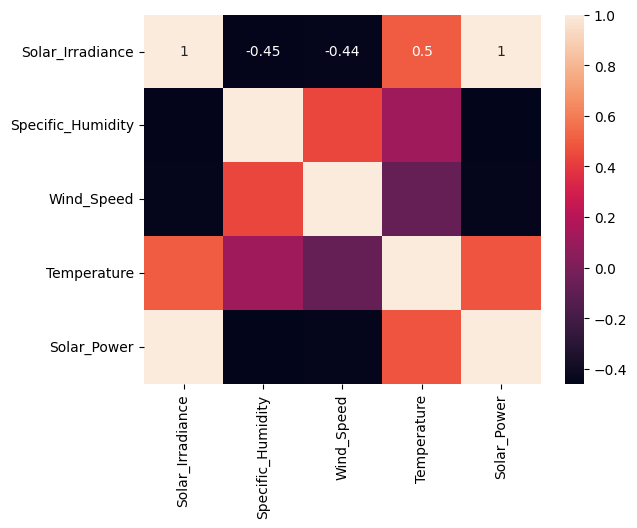

In [6]:
#correlation matrix for the whole dataset
corr= df.corr(numeric_only=True) 
sns.heatmap(corr, annot= True)
plt.show()

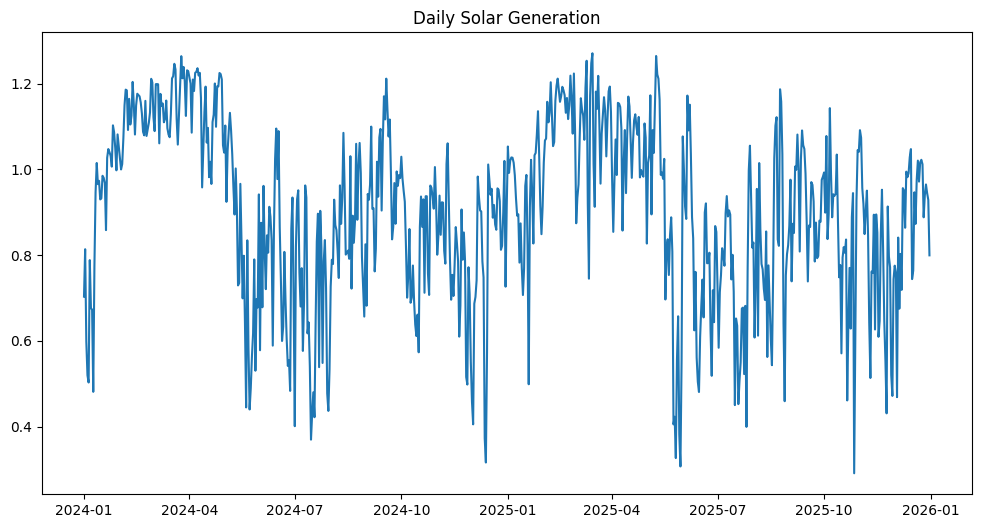

In [7]:
#Visualization of the target- Daily solar generation
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Solar_Power'])
plt.title("Daily Solar Generation")
plt.show()

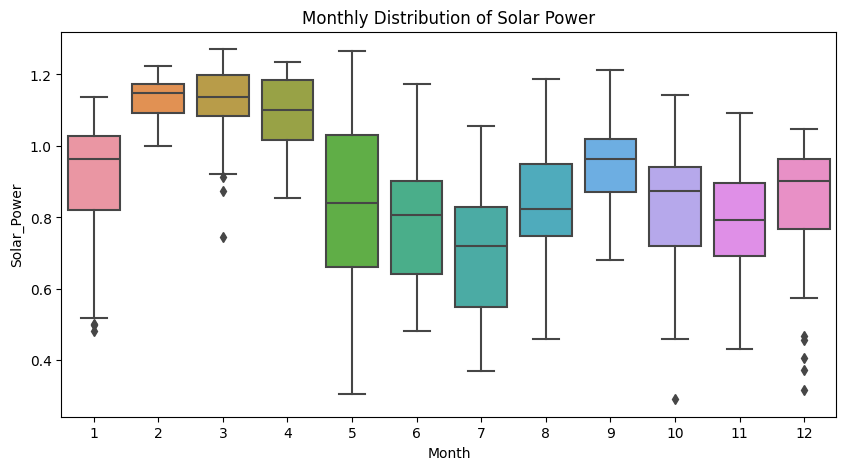

In [8]:
#Visualization of target- Monthly distribution of the solar generation
df['Month'] = df['Date'].dt.month

plt.figure(figsize=(10,5))
sns.boxplot(x='Month', y='Solar_Power', data=df)

plt.title("Monthly Distribution of Solar Power")
plt.show()

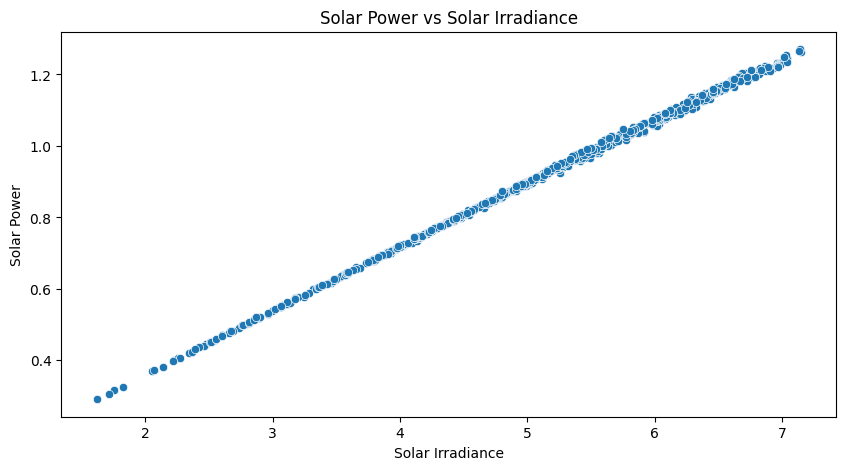

In [9]:
#Visualization of target vs important feature- Solar Power vs Solar Irradiance
plt.figure(figsize=(10,5))
sns.scatterplot(x=df['Solar_Irradiance'], y=df['Solar_Power'])

plt.xlabel("Solar Irradiance")
plt.ylabel("Solar Power")
plt.title("Solar Power vs Solar Irradiance")

plt.show()

## Machine Learning Models:
1. Linear regression- deterministic model
2. Bayesian Regression- probabilistic model
3. XGBoost- partially deterministic model

In [10]:
#train and test splitting
#train 2024 data
#test 2025 data
train = df[df['Date'] < '2025-01-01']
test  = df[df['Date'] >= '2025-01-01']

In [11]:
print("Train size:", train.shape)
print("Test size:", test.shape)

Train size: (366, 7)
Test size: (365, 7)


In [14]:
#model defining along with evaluation metrics
def run_models(features, train, test, target='Solar_Power', plot=True):

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]
    y_test = test[target]

    models = {
        "Linear Regression": LinearRegression(),
        "Bayesian Regression": BayesianRidge(),
        "XGBoost": XGBRegressor(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8
        )
    }

    results = []
    predictions = {}

    for name, model in models.items():

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        predictions[name] = y_pred
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        results.append({
            "Model": name,
            "MAE": mae,
            "RMSE": rmse,
        })

    results_df = pd.DataFrame(results)

    print("\nFeatures Used:", features)
    print("\n")

    if plot:
        plt.figure(figsize=(10,5))
        plt.plot(test['Date'], y_test, label="Actual", linewidth=2)

        for name, pred in predictions.items():
            plt.plot(test['Date'], pred, label=name)

        plt.title(f"Prediction Comparison ({', '.join(features)})")
        plt.legend()
        plt.show()
    return results_df

### Feature importance analysis
We initially use all the four features for the ML models to determine the solar power for test data. Then we remove one of four feature everytime to analyse how the output prediction is affected in the absence of that feature.


Features Used: ['Solar_Irradiance', 'Temperature', 'Specific_Humidity', 'Wind_Speed']




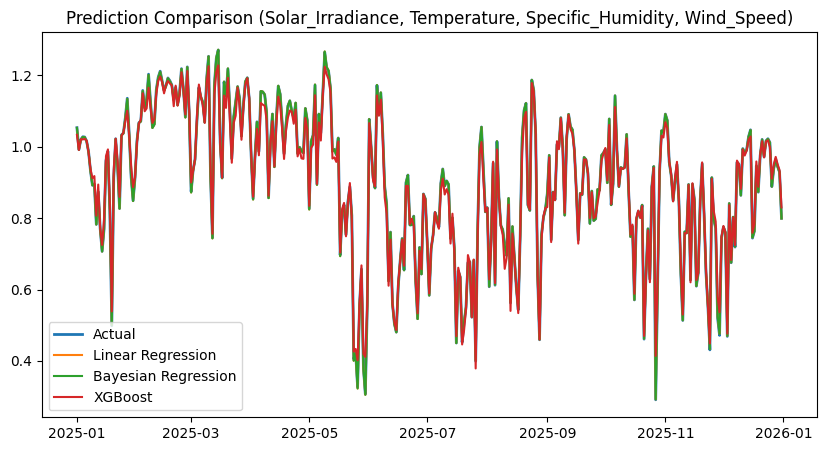

,Model,MAE,RMSE
0,Linear Regression,0.000714,0.001025
1,Bayesian Regression,0.000714,0.001025
2,XGBoost,0.012943,0.018954


In [15]:
#all the features are used
features = [
    'Solar_Irradiance',
    'Temperature',
    'Specific_Humidity',
    'Wind_Speed'
]

run_models(features, train, test, plot=True)


Features Used: ['Temperature', 'Specific_Humidity', 'Wind_Speed']




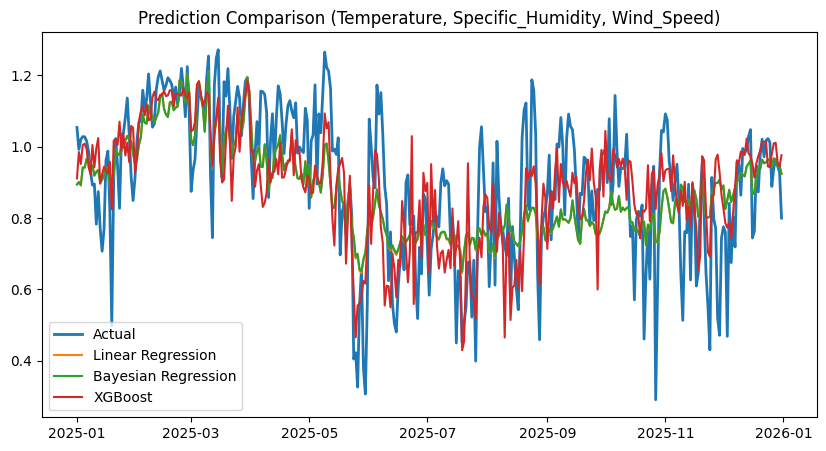

,Model,MAE,RMSE
0,Linear Regression,0.114018,0.146256
1,Bayesian Regression,0.114096,0.146391
2,XGBoost,0.113127,0.145973


In [16]:
#solar irradiance is removed
features_1 = [
    'Temperature',
    'Specific_Humidity',
    'Wind_Speed'
]
run_models(features_1, train, test, plot=True)


Features Used: ['Solar_Irradiance', 'Specific_Humidity', 'Wind_Speed']




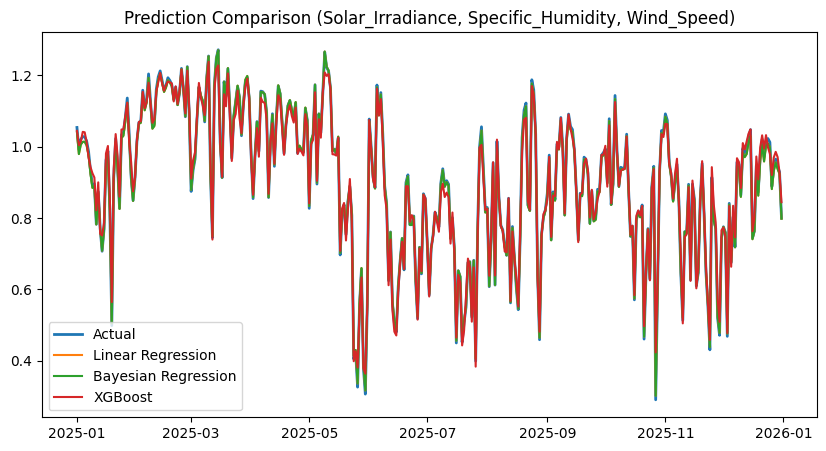

,Model,MAE,RMSE
0,Linear Regression,0.004389,0.005638
1,Bayesian Regression,0.004390,0.005638
2,XGBoost,0.014374,0.019636


In [17]:
#tempertature is removed
features_2 = [
    'Solar_Irradiance',
    'Specific_Humidity',
    'Wind_Speed'
]
run_models(features_2, train, test, plot=True)


Features Used: ['Solar_Irradiance', 'Temperature', 'Wind_Speed']




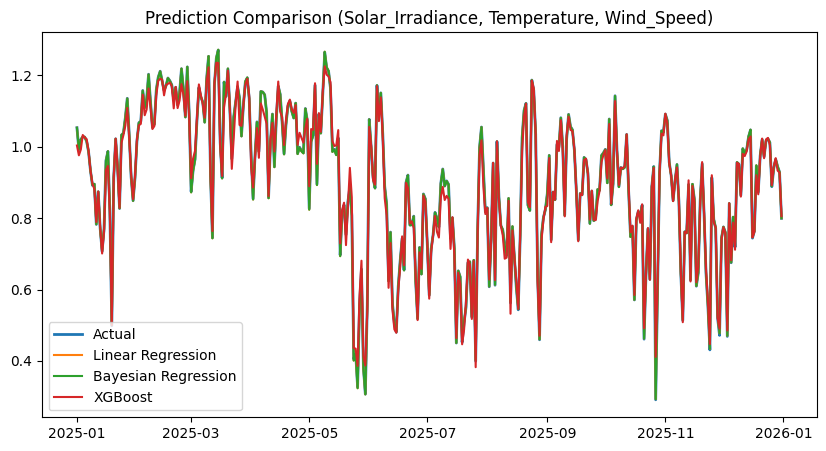

,Model,MAE,RMSE
0,Linear Regression,0.000770,0.001079
1,Bayesian Regression,0.000770,0.001079
2,XGBoost,0.014189,0.020918


In [18]:
#Specific humidity removed
features_3 = [
    'Solar_Irradiance',
    'Temperature',
    'Wind_Speed'
]
run_models(features_3, train, test, plot=True)


Features Used: ['Solar_Irradiance', 'Temperature', 'Specific_Humidity']




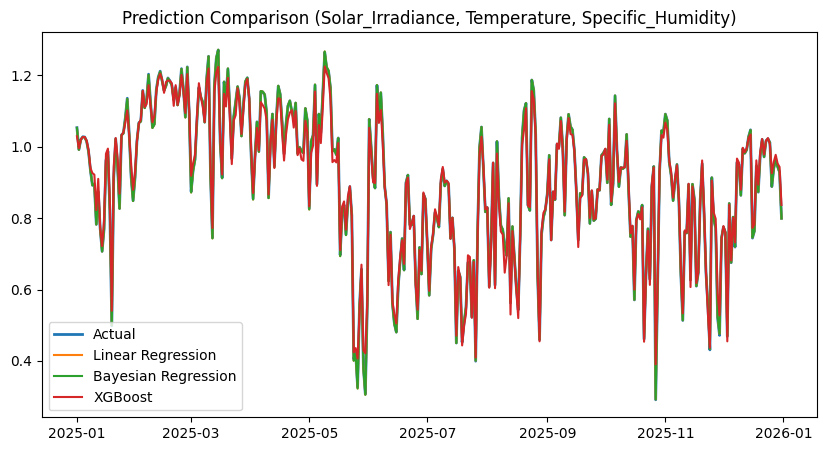

,Model,MAE,RMSE
0,Linear Regression,0.000714,0.001024
1,Bayesian Regression,0.000714,0.001023
2,XGBoost,0.014411,0.020342


In [19]:
#Wind speed removed
features_4 = [
    'Solar_Irradiance',
    'Temperature',
    'Specific_Humidity'
]
run_models(features_4, train, test, plot=True)


Features Used: ['Solar_Irradiance']




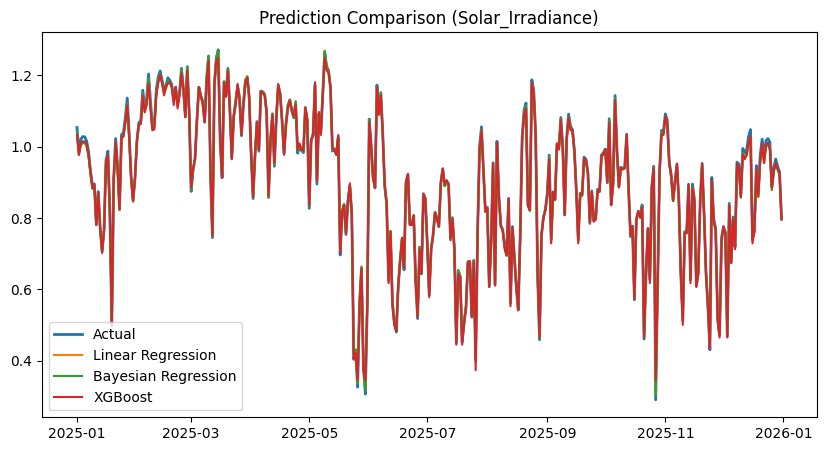

,Model,MAE,RMSE
0,Linear Regression,0.004692,0.006261
1,Bayesian Regression,0.004693,0.006262
2,XGBoost,0.005778,0.008231


In [20]:
#keeping only the major contributing feature
features_5 = ['Solar_Irradiance']
run_models(features_5, train, test, plot=True)

## TIME SERIES ANALYSIS
Since solar power generation is a time series dataset, we will perform some time series analysis and implement time series models- ARIMA, SARIMA, SARIMAX and a simple RNN.

We do:
1. Trend analysis
2. Seasonality analysis
3. ADF test- stationarity test
4. Autocorrelation and Partial Autocorrelation Functions

<Axes: >

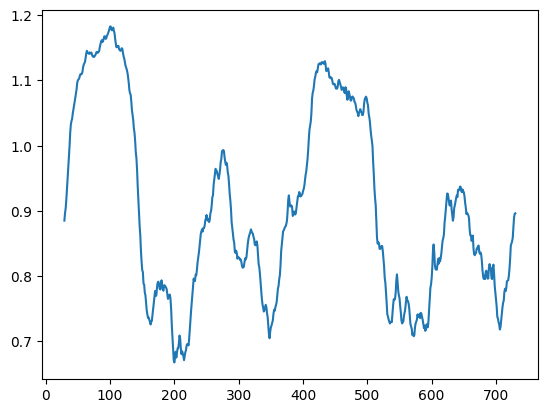

In [21]:
#TREND ANALYSIS
#We carry out trend analysis withe moving average of 30 (monthly) for two years and we could see that the summer/hot months have high production while 
#the cold and rainy months have less solar power production.

df['Solar_Power'].rolling(30).mean().plot()

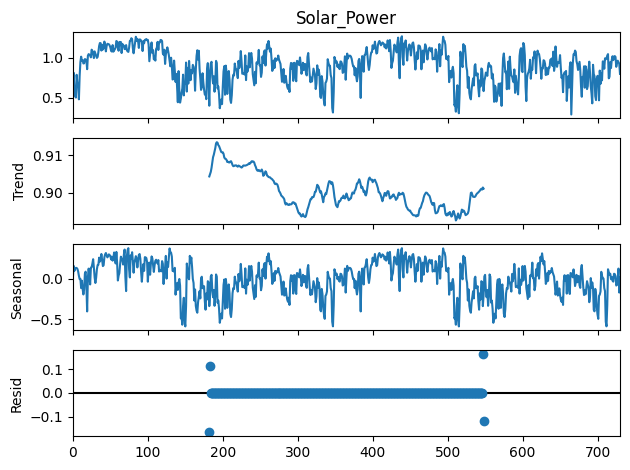

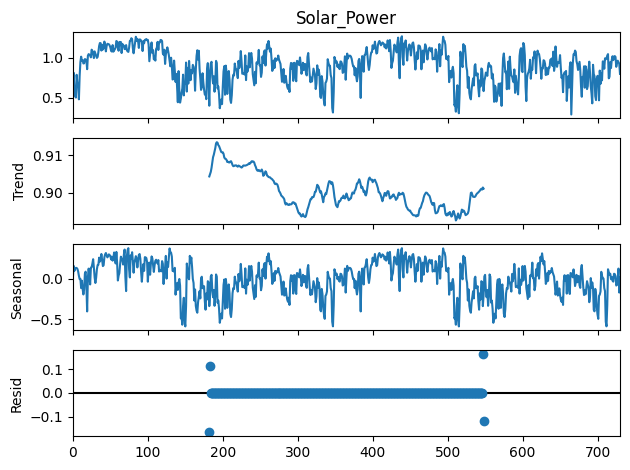

In [22]:
#Seasonality analysis
result = seasonal_decompose(df['Solar_Power'], model='additive', period=365)
result.plot()

In [23]:
#ADF testing for stationarity test: p>0.05--non-stationary; p<0.05-- stationary

result = adfuller(df['Solar_Power'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Lags used:", result[2])
print("Observations:", result[3])
print("Critical values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -5.243149115659662
p-value: 7.173307677768278e-06
Lags used: 4
Observations: 726
Critical values:
1%: -3.4393893552577723
5%: -2.8655292671104644
10%: -2.5688943376666744


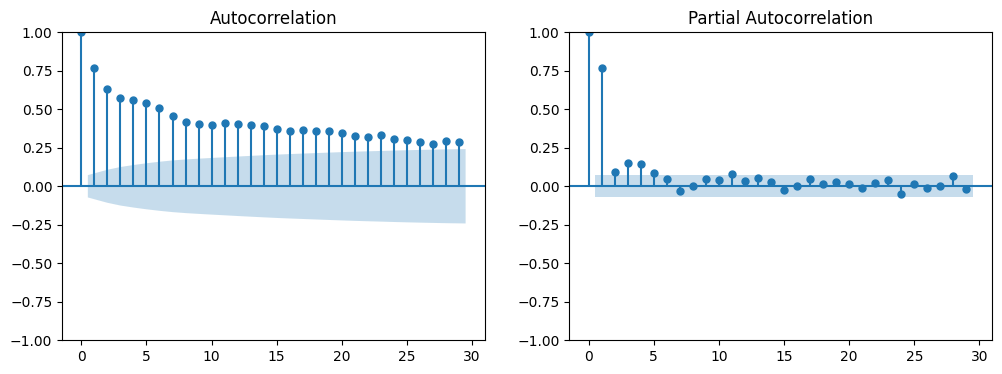

In [24]:
#ACF and PACF
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(df['Solar_Power'], ax=ax[0])
plot_pacf(df['Solar_Power'], ax=ax[1])

plt.show()


## Time series algorithms

In [25]:
#Data preparation
#We make the date column as index for the solar power generation values.
df_ts = df.copy()

df_ts['Date'] = pd.to_datetime(df_ts['Date'])
df_ts = df_ts.set_index('Date')

df_ts = df_ts.sort_index()
y = df_ts['Solar_Power']

In [26]:
train_ts = df_ts.loc[:'2024-12-31'] #train -2024
test_ts  = df_ts.loc['2025-01-01':] #test -2025

y_train = train_ts['Solar_Power']
y_test  = test_ts['Solar_Power']

### ARIMA

In [27]:
model_arima = ARIMA(y_train, order=(1,0,0))
model_arima_fit = model_arima.fit()

pred_arima = model_arima_fit.forecast(steps=len(y_test))
print(model_arima_fit.summary())

C:\Users\Meena Sankari\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Meena Sankari\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Meena Sankari\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:            Solar_Power   No. Observations:                  366
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 244.307
Date:                Fri, 03 Apr 2026   AIC                           -482.614
Time:                        16:31:41   BIC                           -470.907
Sample:                    01-01-2024   HQIC                          -477.962
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9022      0.040     22.724      0.000       0.824       0.980
ar.L1          0.8063      0.035     23.329      0.000       0.739       0.874
sigma2         0.0154      0.001     13.445      0.0

### SARIMA

In [28]:
model_sarima = SARIMAX(
    y_train,
    order=(1,0,0),
    seasonal_order=(1,0,0,365)
)

model_sarima_fit = model_sarima.fit()

pred_sarima = model_sarima_fit.forecast(steps=len(y_test))
print(model_sarima_fit.summary())

C:\Users\Meena Sankari\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Meena Sankari\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Meena Sankari\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


                                      SARIMAX Results                                      
Dep. Variable:                         Solar_Power   No. Observations:                  366
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 365)   Log Likelihood                 226.450
Date:                             Fri, 03 Apr 2026   AIC                           -446.899
Time:                                     16:53:38   BIC                           -435.191
Sample:                                 01-01-2024   HQIC                          -442.247
                                      - 12-31-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9895      0.009    115.965      0.000       0.973       1.006
ar.S.L365      0.9732      

### SARIMAX

In [29]:
#exogenous variables/features affecting solar power generation
exog_features = [
    'Solar_Irradiance',
    'Temperature',
    'Specific_Humidity',
    'Wind_Speed'
]

In [30]:
X_train = train_ts[exog_features]
X_test  = test_ts[exog_features]

In [31]:
model_sarimax = SARIMAX(
    y_train,
    exog=X_train,
    order=(1,0,0),
    seasonal_order=(1,0,0,365)
)

model_sarimax_fit = model_sarimax.fit()

pred_sarimax = model_sarimax_fit.forecast(
    steps=len(y_test),
    exog=X_test
)
print(model_sarimax_fit.summary())

C:\Users\Meena Sankari\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Meena Sankari\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                         Solar_Power   No. Observations:                  366
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 365)   Log Likelihood                1813.488
Date:                             Fri, 03 Apr 2026   AIC                          -3612.977
Time:                                     17:11:36   BIC                          -3585.659
Sample:                                 01-01-2024   HQIC                         -3602.121
                                      - 12-31-2024                                         
Covariance Type:                               opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Solar_Irradiance      0.1794      0.000   1166.868      0.000       0.179       0.180
Temper

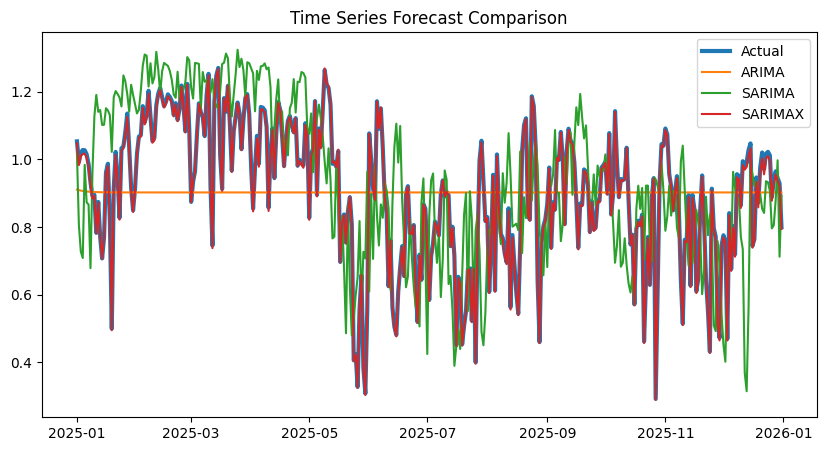

In [32]:
plt.figure(figsize=(10,5))

plt.plot(y_test.index, y_test, label="Actual", linewidth=3)

plt.plot(y_test.index, pred_arima, label="ARIMA")
plt.plot(y_test.index, pred_sarima, label="SARIMA")
plt.plot(y_test.index, pred_sarimax, label="SARIMAX")

plt.title("Time Series Forecast Comparison")
plt.legend()
plt.show()

### RECURRENT NEURAL NETWORK

In [33]:
features = [
    'Solar_Irradiance',
    'Temperature',
    'Specific_Humidity',
    'Wind_Speed'
]

target = 'Solar_Power'

In [34]:
X_train = train[features].values
X_test = test[features].values

y_train = train[target].values
y_test = test[target].values

In [35]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train.reshape(-1,1))
y_test = scaler_y.transform(y_test.reshape(-1,1))

In [36]:
def create_sequences(X, y, window=7):

    X_seq, y_seq = [], []

    for i in range(window, len(X)):
        X_seq.append(X[i-window:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, 7)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, 7)

In [37]:
model = Sequential([
    SimpleRNN(16, activation='tanh', input_shape=(7, len(features))),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

C:\Users\Meena Sankari\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 16)                  │             336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 353 (1.38 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
history = model.fit(
    X_train_seq,
    y_train_seq,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - loss: 0.1332 - val_loss: 0.0424
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0431 - val_loss: 0.0461
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0324 - val_loss: 0.0392
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0286 - val_loss: 0.0384
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0252 - val_loss: 0.0369
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0233 - val_loss: 0.0356
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0218 - val_loss: 0.0344
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0210 - val_loss: 0.0339
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0203 - val_loss: 0.0327
Epoch 10/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0195 - val_loss: 0.0319
Epoch 11/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0191 - val_loss: 0.0310
Epoch 12/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0

In [39]:
y_pred = model.predict(X_test_seq)
y_pred = scaler_y.inverse_transform(y_pred)
y_test_actual = scaler_y.inverse_transform(y_test_seq)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step


In [42]:

mae_rnn = mean_absolute_error(y_test_actual, y_pred)
rmse_rnn = np.sqrt(mean_squared_error(y_test_actual, y_pred))

print("RNN MAE:", mae_rnn)
print("RNN RMSE:", rmse_rnn)

RNN MAE: 0.11883845735502496
RNN RMSE: 0.15096978841768158


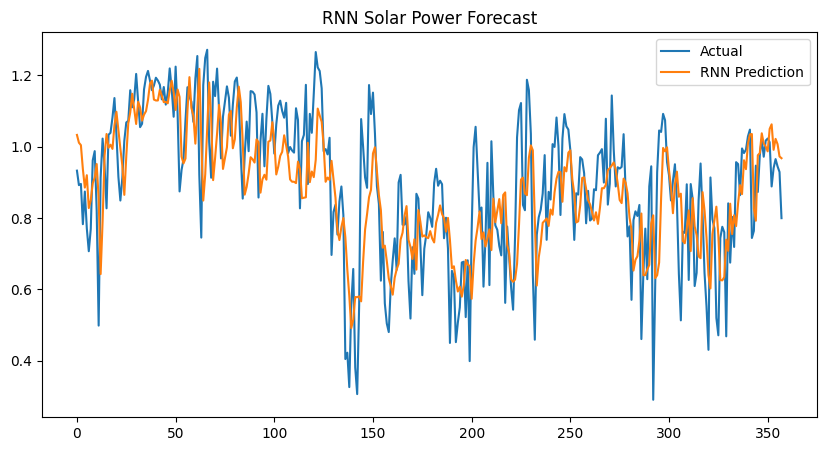

In [43]:

plt.figure(figsize=(10,5))

plt.plot(y_test_actual, label="Actual")
plt.plot(y_pred, label="RNN Prediction")

plt.legend()
plt.title("RNN Solar Power Forecast")

plt.show()

In [44]:
results_ts = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA", "SARIMAX", "RNN"],
    
    "MAE": [
        mean_absolute_error(y_test, pred_arima),
        mean_absolute_error(y_test, pred_sarima),
        mean_absolute_error(y_test, pred_sarimax),
        mae_rnn
    ],
    
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_arima)),
        np.sqrt(mean_squared_error(y_test, pred_sarima)),
        np.sqrt(mean_squared_error(y_test, pred_sarimax)),
        rmse_rnn
    ]
})

results_ts


,Model,MAE,RMSE
0,ARIMA,0.289921,0.356138
1,SARIMA,0.335390,0.388820
2,SARIMAX,0.280003,0.280244
3,RNN,0.118838,0.150970


## Sensitivity Analysis

In [45]:
def get_trained_models(features, train, target='Solar_Power'):

    X_train = train[features]
    y_train = train[target]

    models = {
        "Linear Regression": LinearRegression(),
        "Bayesian Regression": BayesianRidge(),
        "XGBoost": XGBRegressor(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8
        )
    }

    trained_models = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        trained_models[name] = model

    return trained_models


Features Used: ['Solar_Irradiance', 'Temperature', 'Specific_Humidity', 'Wind_Speed']




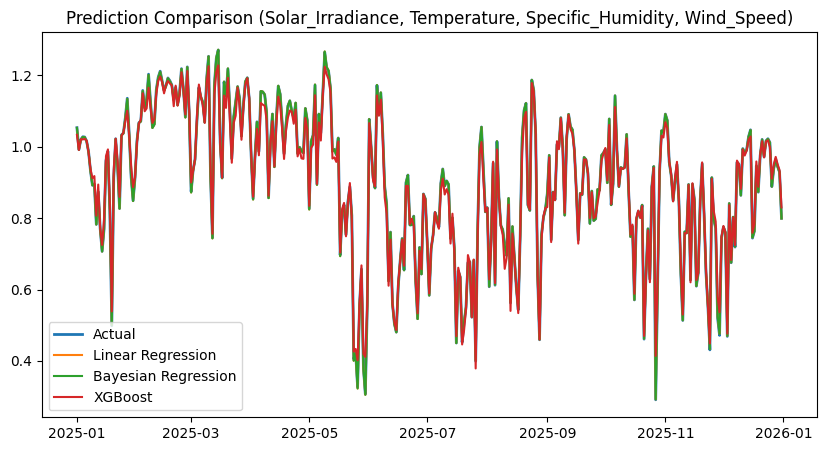

In [46]:
#Running original function
results_df = run_models(features, train, test)

#Getting trained models separately
trained_models = get_trained_models(features, train)

#Preparing test data
X_test = test[features]

In [47]:
#residual sensitivity
def residual_sensitivity(trained_models, X_test):

    results = {}

    for name, model in trained_models.items():

        covs = {}

        for col in X_test.columns:

            X_temp = X_test.copy()
            X_temp[col] = X_test[col].mean()

            y_pred = model.predict(X_temp)

            mu = np.mean(y_pred)
            sigma = np.std(y_pred)

            # "covariance"
            cov_i = sigma / mu  

            covs[col] = cov_i

        total = sum(covs.values())

        rcov = {k: v/total for k,v in covs.items()}

        results[name] = pd.DataFrame({
            "Feature": covs.keys(),
            "Cov_i": covs.values(),
            "RCov": rcov.values()
        }).sort_values(by="RCov", ascending=False)

    return results

In [48]:
res_results = residual_sensitivity(trained_models, X_test)

for model, df in res_results.items():
    print(f"\nModel: {model}")
    print(df)


Model: Linear Regression
             Feature     Cov_i      RCov
1        Temperature  0.227000  0.332439
2  Specific_Humidity  0.224669  0.329024
3         Wind_Speed  0.224351  0.328559
0   Solar_Irradiance  0.006813  0.009978

Model: Bayesian Regression
             Feature     Cov_i      RCov
1        Temperature  0.227000  0.332439
2  Specific_Humidity  0.224668  0.329024
3         Wind_Speed  0.224351  0.328559
0   Solar_Irradiance  0.006813  0.009978

Model: XGBoost
             Feature     Cov_i      RCov
3         Wind_Speed  0.212303  0.324271
1        Temperature  0.212225  0.324152
2  Specific_Humidity  0.207477  0.316899
0   Solar_Irradiance  0.022704  0.034678


In [49]:
#We use only the test dataset for these analysis.
def variance_sensitivity(trained_models, X_test):

    results = {}

    for name, model in trained_models.items():

        # original prediction
        y_orig = model.predict(X_test)
        mu_orig = np.mean(y_orig)
        sigma_orig = np.std(y_orig)

        covs = {}

        for col in X_test.columns:

            X_temp = X_test.copy()
            X_temp[col] = X_test[col].mean()

            y_new = model.predict(X_temp)

            sigma_new = np.std(y_new)

            cov_i = (sigma_orig - sigma_new) / mu_orig

            covs[col] = cov_i

        total = sum(covs.values())

        rcov = {k: v/total for k,v in covs.items()}

        results[name] = pd.DataFrame({
            "Feature": covs.keys(),
            "Cov_i": covs.values(),
            "RCov": rcov.values()
        }).sort_values(by="RCov", ascending=False)

    return results

In [50]:
var_results = variance_sensitivity(trained_models, X_test)

for model, df in var_results.items():
    print(f"\nModel: {model}")
    print(df)

#Solar Irradiance is the direct contribution of the solar power generation in this dataset. So we make that feature a constant valued feature making the
#standard deviation almost zero and then dividing by the mean value gives very small covariance value. This results in smaller relative covariance of the
#important feature.


Model: Linear Regression
             Feature     Cov_i      RCov
0   Solar_Irradiance  0.217541  1.013782
3         Wind_Speed  0.000003  0.000015
2  Specific_Humidity -0.000315 -0.001466
1        Temperature -0.002646 -0.012331

Model: Bayesian Regression
             Feature     Cov_i      RCov
0   Solar_Irradiance  0.217541  1.013782
3         Wind_Speed  0.000003  0.000015
2  Specific_Humidity -0.000315 -0.001466
1        Temperature -0.002646 -0.012331

Model: XGBoost
             Feature     Cov_i      RCov
0   Solar_Irradiance  0.191764  0.936176
2  Specific_Humidity  0.010182  0.049705
3         Wind_Speed  0.001793  0.008755
1        Temperature  0.001099  0.005364


### UNCERTAINITY ANALYSIS

In [51]:
#we slightly change the features of the test dataset.
def uncertainty(trained_models, X_test, percent=0.15, n_sim=20):

    results = {}

    for name, model in trained_models.items():

        all_preds = []

        for _ in range(n_sim):

            X_temp = X_test.copy()
#we add some variations to the features and making it a noise for the model to understand the performance in a noisy unpredictable envicronment
            for col in X_test.columns:
                variation = percent * X_test[col]
                noise = np.random.uniform(-variation, variation)
                X_temp[col] = X_test[col] + noise

            y_pred = model.predict(X_temp)
            all_preds.append(y_pred)

        results[name] = np.array(all_preds)

    return results

In [52]:
unc_5 = uncertainty(trained_models, X_test, percent=0.05)
unc_10 = uncertainty(trained_models, X_test, percent=0.10)
unc_15 = uncertainty(trained_models, X_test, percent=0.15)

C:\Users\Meena Sankari\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Meena Sankari\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Meena Sankari\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


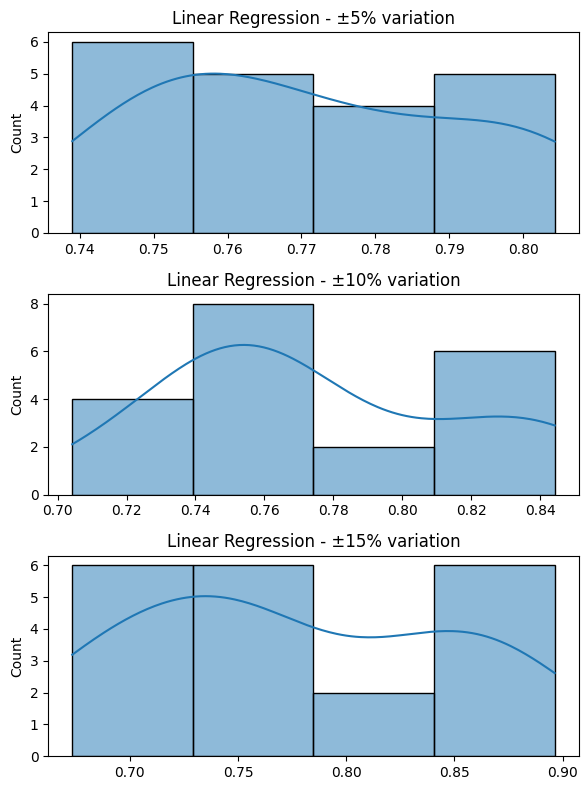

C:\Users\Meena Sankari\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Meena Sankari\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Meena Sankari\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


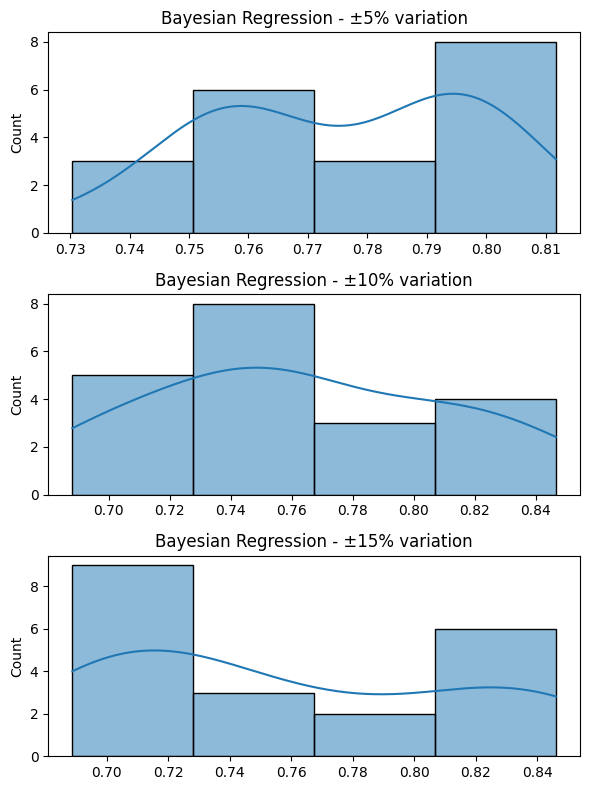

C:\Users\Meena Sankari\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Meena Sankari\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Meena Sankari\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


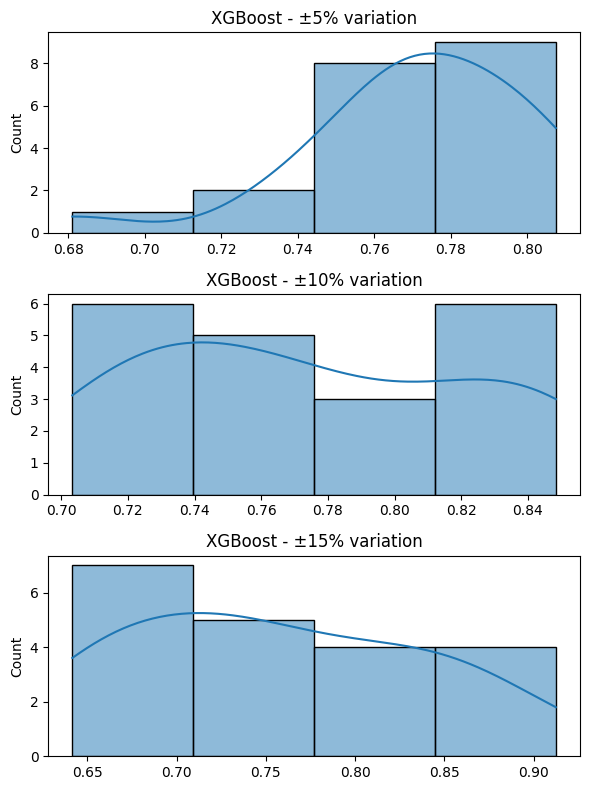

In [53]:
sample_index = 12 

for model_name in trained_models.keys():

    plt.figure(figsize=(6,8))

    for i, (label, unc) in enumerate([
        ("±5%", unc_5),
        ("±10%", unc_10),
        ("±15%", unc_15)
    ]):

        data = unc[model_name][:, sample_index]

        plt.subplot(3,1,i+1)
        sns.histplot(data, bins=4, kde=True)
        plt.title(f"{model_name} - {label} variation")

    plt.tight_layout()
    plt.show()